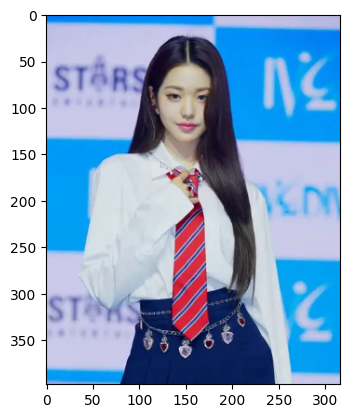

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

path = '/content/idol_girl.png'

img = cv2.imread(path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

In [ ]:
# 기본 정보 파악 (가로, 세로)
img.shape

(398, 317, 3)

In [ ]:
height, width = img.shape[:2]
print(height)
print(width)

398
317


<function matplotlib.pyplot.show(close=None, block=None)>

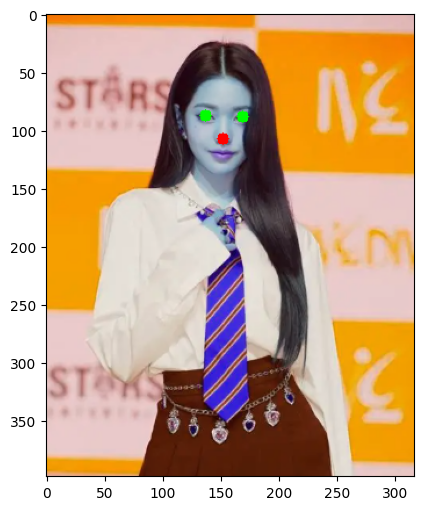

In [ ]:
eye_left_x, eye_left_y = int(width * 0.435), int(height * 0.220)    # 왼쪽 눈
eye_right_x, eye_right_y = int(width * 0.535), int(height * 0.222)  # 오른쪽 눈
nose_x, nose_y = int(width * 0.48), int(height * 0.27)              # 코

# 원본 이미지 위에 좌표를 찍어서 확인
marked_img = img.copy()
cv2.circle(marked_img, (eye_left_x, eye_left_y), 5, (0, 255, 0), -1)    # 초록색 점
cv2.circle(marked_img, (eye_right_x, eye_right_y), 5, (0, 255, 0), -1)  # 초록색 점
cv2.circle(marked_img, (nose_x, nose_y), 5, (0, 0, 255), -1)            # 빨간색 점

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(marked_img, cv2.COLOR_BGR2RGB))
plt.show

In [ ]:
np.indices((2,3))
# 지정된 크기(2*3 행렬) 행 인덱스와 열 인덱스 배열 생성하는 함수
# 첫번째 행렬 (행 인덱스)>> y좌표 지도
# >> 각 칸의 세로 위치(몇번째 줄이냐)

# 두번째 행렬 (열 인덱스)>> x좌표 지도
# >> 각 칸의 가로 위치(몇번째 칸인지)

array([[[0, 0, 0],
        [1, 1, 1]],

       [[0, 1, 2],
        [0, 1, 2]]])

In [ ]:
# 왜곡 정도를 다르게 하는 식
# 이동할 좌표 = 중심점 + (원래거리 * 요인(factor))

반지름 = 100
강도 = 1.8

# 중심(distance=0)
요인_0 = (0/100) ** 1.8
print(요인_0)   # 중심일 경우 요인 = 0

# 중심 근처(distance=1)
요인_1 = (1/100) ** 1.8
print(요인_1) # 중간일 경우 요인 = 0.00025118864315095795
# 중심 근처에 있으면 중심점 쪽으로 바짝 당겨져요

# 가장자리(distance=100)
# >> 요인(factor) = 1
# >> 왜곡 0% (제자리에)
요인_100 = (100/100) ** 1.8
print(요인_100) # 가장자리일 경우 요인 = 1

# 중간(distance=50)
요인_50 = (50/100) ** 1.8
print(요인_50) # 중간일 경우 요인 = 0.287

# 중심점에 가까울수록 왜곡이 심함

0.0
0.00025118864315095795
1.0
0.2871745887492587


In [ ]:
# import numpy as np

# # 중심점 x좌표 200, y좌표 150, 반지름 100, 강도 1.8
# center_x, center_y = 200, 150
# radius = 100
# strength = 1.8

# # 테스트할 특정 픽셀 좌표(210, 150)
# test_x, test_y = 210, 150

# # 중심점에서 거리 계산
# delta_x = test_x - center_x
# delta_y = test_y - center_y
# distance = np.sqrt(delta_x ** 2 + delta_y ** 2)

# print(delta_x, delta_y)
# print(distance)

# # 왜곡 계수(factor) 계산
# factor = (distance / radius) ** strength
# print(factor)

# # 변형 후 새롭게 매핑될 좌표
# new_x = center_x + delta_x * factor
# new_y = center_y + delta_y * factor

# print(f'변형 전 좌표: {test_x}, {test_y}')
# print(f'변형 후 좌표: {new_x:.1f}, {new_y:.1f}')

In [ ]:
def plastic_filter(img, center_x, center_y, radius, strength):
    h, w = img.shape[:2]

    # 1. 원본 이미지 크기와 1:1로 매칭되는 빈 좌표 지도(map) 생성
    map_y, map_x = np.indices((h,w), dtype=np.float32)

    # 2. 지정된 중심점(예를 들어 눈)으로 부터 모든 픽셀까지 거리 (r)구하기
    delta_x = map_x - center_x
    delta_y = map_y - center_y
    distance = np.sqrt(delta_x**2 + delta_y**2)

    # 3. 지정한 반지름(radius)안에 들어오는 픽셀들만 골라내는 마스크 생성
    mask = (distance < radius)

    # 4. 수학적 왜곡 공식 적용
    # 거리에 따라 왜곡의 정도를 다르게 하는 식
    # 거리를 반지름 비율로 나눈 뒤, strength 제곱을 하여 픽셀을 밀거나 당길 강도를 정한다.
    factor = (distance / radius) ** strength

    # 5. 좌표 변형-마스크 영역 내부의 픽셀 좌표 지도 조작
    map_x[mask] = center_x + delta_x[mask] * factor[mask]
    # 변형 후 좌표 = 중심점 + 상대위치*강도
    # mask >> [y, x]
    map_y[mask] = center_y + delta_y[mask] * factor[mask]

    # 6. 실제 왜곡을 적용: 완성된 좌표 지도를 가지고 실제 픽셀들을 이동 시킨다
    distorted_img = cv2.remap(img, map_x, map_y,
                              interpolation=cv2.INTER_LINEAR, # 주변 픽셀들의 평균값 사용
                              borderMode=cv2.BORDER_REFLECT)  # 경계면이 자연스럽게 반사(깨짐 방지)

    # cv2.remap()이란: 변형된 좌표 맵 사용해서 새로운 이미지 생성
    # new_y, new_x = input(map_y[y,x], map_x[y,x])
    # map_x[0,0] = 10, map_y[0,0] = 5 >> 출력 [0,0] = 입력[5,10]
    return distorted_img

In [ ]:
# 단계 1: 왼쪽 눈을 왕눈이로 만들어봐요 (strength > 1 >> 확대)
step1 = plastic_filter(img, center_x = eye_left_x, center_y=eye_left_y, radius=5, strength=1.2)

# 단계 2: 변형된 이미지(step1) 받아가지고, 오른쪽 눈을 왕눈이로 만들어봐요 (strength > 1 >> 확대)
step2 = plastic_filter(step1, center_x = eye_right_x, center_y=eye_right_y, radius=5, strength=1.2)

# 단계 3: 양쪽 눈이 커진 상태(step2)에서 코는 줄여볼게요 (strength < 1 >> 축소)
final_img = plastic_filter(step2, center_x = nose_x, center_y=nose_y, radius=7, strength=0.5)

(np.float64(-0.5), np.float64(316.5), np.float64(397.5), np.float64(-0.5))

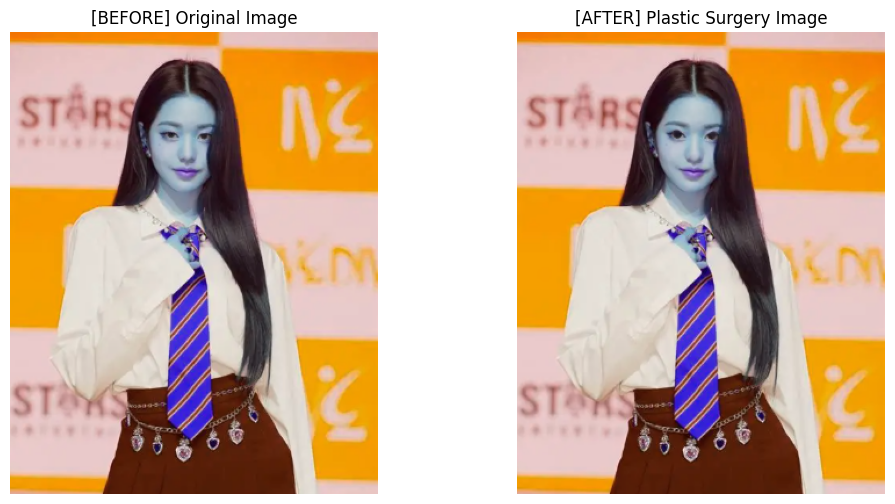

In [ ]:
original_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plastic_rgb = cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))

plt.subplot(1,2,1)
plt.imshow(original_rgb)
plt.title("[BEFORE] Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(plastic_rgb)
plt.title("[AFTER] Plastic Surgery Image")
plt.axis('off')
